# Ensemble Methods 

## Utils (skipped)

In [4]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [5]:
def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):

    # setup marker generator and color map up for up to 5 classes
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'green', 'blue', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.4, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # Plot samples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1],
                    alpha=0.8, color=cmap(idx),
                    marker='x', label=cl)

    # Plot test samples if they exist
    if not test_idx is None:
        X_test, y_test = X[test_idx, :], y[test_idx]
        for idx, cl in enumerate(np.unique(y_test)):
            plt.scatter(x=X_test[y_test == cl, 0], y=X_test[y_test == cl, 1],
                        alpha=1, color=cmap(idx),
                        linewidths=1, marker='o', s=55, label=f'test {cl}')
    plt.legend()
    plt.show()

## Plan

1. Decision Trees
2. Bagging (e.g. `RandomForest`)
3. Boosting (e.g. `GradientBoosting`)
4. Stacking

# 1. Decision Trees

Decision Trees are hierarchical supervised learning algorithms

They primarily help us with:
- classification and Regression
- non-linear modeling
- breaking down data through binary decisions

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/binary_decision_tree.png' width=400 style='margin:auto'> 

## 1.1 🖥 [`DecisionTreeClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)


In [6]:
from sklearn.datasets import load_iris

iris = load_iris()
data = pd.DataFrame(data= np.c_[iris['data'], iris['target']],
                     columns= iris['feature_names'] + ['target'])
data.drop(columns=['sepal length (cm)', 'sepal width (cm)'], inplace=True)
data

,petal length (cm),petal width (cm),target
0,1.4,0.2,0.0
1,1.4,0.2,0.0
2,1.3,0.2,0.0
3,1.5,0.2,0.0
4,1.4,0.2,0.0
...,...,...,...
145,5.2,2.3,2.0
146,5.0,1.9,2.0
147,5.2,2.0,2.0
148,5.4,2.3,2.0


In [7]:
X = data.drop(columns=['target']).values
y = data.target.values

In [8]:
# Instantiate and train model
from sklearn.tree import DecisionTreeClassifier
tree_clf = DecisionTreeClassifier(max_depth=2, random_state=2)
tree_clf.fit(X,y)

DecisionTreeClassifier(max_depth=2, random_state=2)

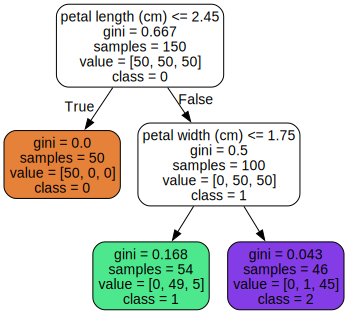

In [13]:
import graphviz

# Export model graph
from sklearn.tree import export_graphviz
export_graphviz(tree_clf, out_file="iris_tree.dot",
                feature_names=data.drop(columns=['target']).columns,
                class_names=['0','1','2'],
                rounded=True, filled=True)

# Import model graph
with open("iris_tree.dot") as f:
    dot_graph = f.read()
    display(graphviz.Source(dot_graph))

### Jargon

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/decision_tree_jargon.png' width=700 style='margin:auto'> 

### Gini Index

The Gini index measures the ability of each feature to **separate** the data

It calculates the **impurity** of each node, between [0, 1]; the lower the better

$$\text{Gini(node)} = 1 - \sum p_i^2$$

$p_i$ being the ratio between the observations in a class $i$ and the total number of observations remaining at a given node

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/decision_tree_jargon.png' width=500 style='margin:auto'> 

In [14]:
# Calculate gini of root node
1 - (50/150)**2 - (50/150)**2 - (50/150)**2

0.6666666666666665

In [15]:
# Calcultate gini green leaf
1 - 0**2 - (49/54)**2 - (5/54)**2

0.1680384087791495

### How Do We "Grow" a Tree?

The tree's structure is defined through the following steps:
1. Start at root node, which contains your entire dataset
2. Try various combinations of **(feature, threshold)** combos; each would split your dataset into 2 child nodes
3. For each combination, compute the **weighted average Gini index** of both child nodes (weighted by number of instances)
4. Select the **(feature, threshold)** combo yielding the **lowest** index (i.e. the "purest child nodes")
5. Split the dataset in two using this rule
6. Repeat step 2 for both subsets
7. Stop when no feature improves node impurity (at what risk?)

[Source: CART algorithm (Aurelien Geron)](https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/tree_growth_aurelien_geron.png)

### Predicting 

- A new point is passed through the tree from top to bottom until it reaches a leaf 
- The most represented class in that leaf is the predicted class for a given data point

*Example*: consider the following data point: `X_new = [4(length), 1(width)]`

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/decision_tree_predict.png' width=500 style='margin:auto'> 

In [16]:
# Let's predict the class of a new flower
print(tree_clf.predict([[4,1]]))

[1.]


In [17]:
# Predict proba
print(tree_clf.predict_proba([[4,1]]))

[[0.         0.90740741 0.09259259]]


<br>

❗️*90% is not a "probability" per se, it corresponds to the ratio of classes in the node*

<br>

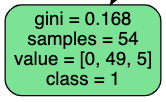

Trees are not _calibrated_ classifiers (as opposed to logistic regressors)

### Think about decision trees as "orthogonal" classifiers

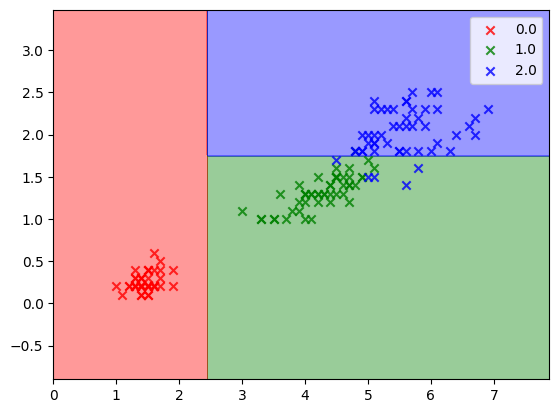

In [18]:
# Hand-made function to plot all predictions
plot_decision_regions(X, y, classifier=tree_clf)

👇 scikit-learn classifier comparison ([source](https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html))
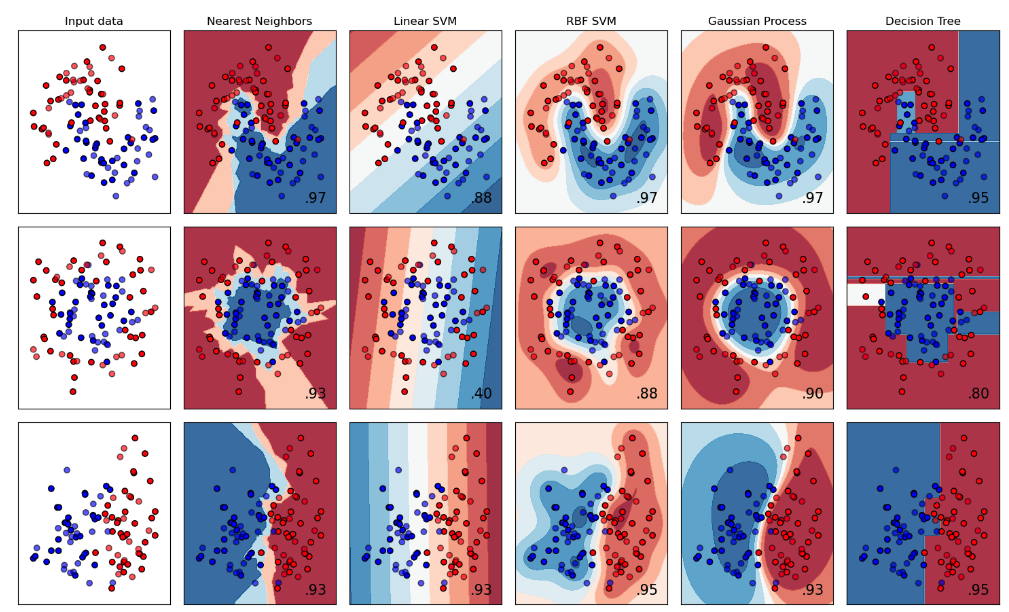

## 1.2 [`DecisionTreeRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html)

The goal of regression trees is to predict a continuous value, they are "grown" differently than classification trees 

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/regression_tree_14.png' width=800 style='margin:auto' align = left> 


### Growing the Regression Tree

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/regression_tree_1.png' width=500 style='margin:auto' align = left> 

- Select a <font color=red>threshold</font> for drug dosage
- On both sides, compute the **sum of squared residuals** (SSR) between the <font color=green>average of each side</font> and the ground truth
- Report the <font color=purple>weighted average SSR of both sides</font>, weighted by the number of data points ⤵

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/regression_tree_6.png' width=1000 style='margin:auto' align = left> 

- Move the <font color=red>threshold</font> to the right, and compute the <font color=purple>weighted average SSR</font> again ⤵
<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/regression_tree_7.png' width=1000 style='margin:auto' align = left> 

The <font color=red>threshold</font> that minimizes the residuals becomes the **root node** of the tree

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/regression_tree_8.png' width=1000 style='margin:auto' align = left> 

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/regression_tree_9.png' width=1000 style='margin:auto' align = left> 

We could further split the points below the dosage of 14.5, but we probably shouldn't

<br>
<h3 style="text-align: center;">Why?</h3>

⚠️ We would be **overfitting**!

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/regression_tree_10.png' width=400 style='margin:auto' align = left> 

Instead, stop splitting and use the average value of all points within the group to **generalize**

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/regression_tree_12.png' width=1000 style='margin:auto' align = left> 

### ⚠️ Controlling Overfitting

- **Decision trees must be tuned!**
- Default parameters will almost certainly overfit
    - Control split with `min_samples_split`
    - Control leaves with `min_samples_leaf`
    - Control tree depth with `max_depth`

#### `min_samples_split`

- Specifies the minimum number of samples required to split an internal node
- In the example, it is set to `7`

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/regression_tree_14.png' width=500 style='margin:auto' align = left> 

#### `min_samples_leaf` 
- Minimum number of samples for node to be a leaf (the smaller the number, the more it overfits)

#### `max_depth`

- Maximum depth of the tree (the larger the number, the more it overfits)

## 💻  Variance Illustrated

#### Regression

The `flats` dataset is available [here](https://wagon-public-datasets.s3.amazonaws.com/flats.csv)

In [19]:
import pandas as pd
data = pd.read_csv('https://wagon-public-datasets.s3.amazonaws.com/flats.csv')
data.head(3)

,price,bedrooms,surface,floors
0,274.0,3,1830,2.0
1,500.0,4,2120,1.0
2,320.0,3,1260,1.0


In [20]:
X = data[['bedrooms','surface','floors']]
y = data['price']

In [21]:
def plot_histogram_cv_results(cv_results):
    # Calculating the std and the mean
    std = cv_results['test_score'].std()
    mean = cv_results['test_score'].mean()

    # Getting the number of folds
    n_cv = len(cv_results['test_score'])

    # Building plot
    plt.hist(cv_results['test_score'], bins=n_cv)

    # Creating red lines
    plt.vlines(mean, 0, 3, color='red', label=f'mean = {mean:.2f}')
    plt.hlines(
        3, mean - 1/2 * std, mean + 1/2 * std,
        color='red', label=f'std = {std:.2f}', ls='dotted'
    )

    # Setting the title
    plt.title('Histogram of R2 Scores During Cross-Validation')

    # Setting the labels and xlim
    plt.xlim((-1, 1))

    plt.xlabel('r2')
    plt.ylabel('number of folds')

    # Showing the legend
    plt.legend(loc='upper left')

    plt.show()

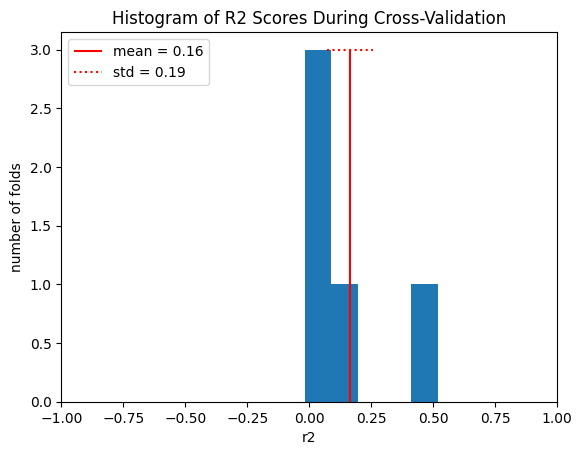

In [22]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_validate

tree = DecisionTreeRegressor()

cv_results = cross_validate(tree, X, y, scoring = "r2", cv=5)

# Custom method
plot_histogram_cv_results(cv_results)

#### Classification

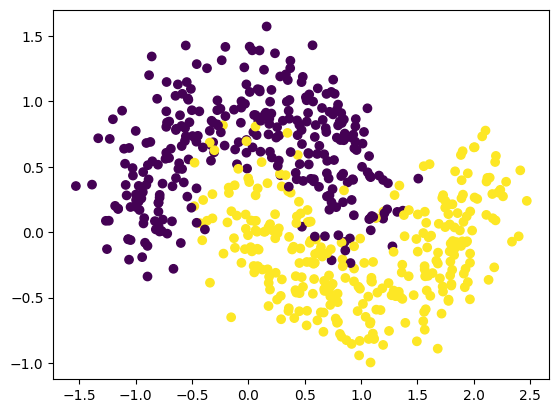

In [23]:
from sklearn.datasets import make_moons

n=600
X_moon,y_moon = make_moons(n_samples=n, noise=0.25, random_state=0)

plt.scatter(X_moon[:,0], X_moon[:,1], c=y_moon)

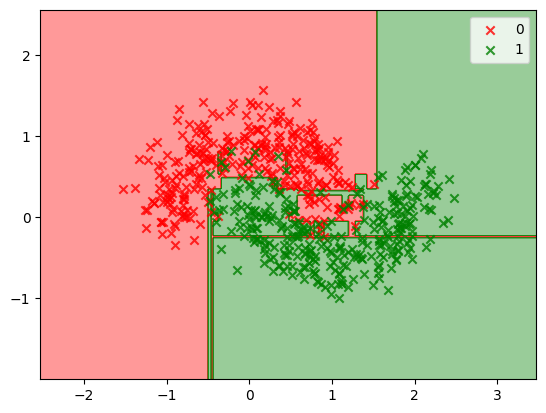

In [24]:
from sklearn.tree import DecisionTreeClassifier
from ipywidgets import interact

#@interact(max_depth=10)
def plot_classifier(max_depth):
    clf = DecisionTreeClassifier(max_depth=max_depth)
    clf.fit(X_moon, y_moon)
    plot_decision_regions(X_moon, y_moon, classifier=clf)

plot_classifier(max_depth=10)

## Pros and Cons of Decision Trees

👍 Advantages
- No scaling necessary
- Resistant to outliers
- Intuitive and easy to interpret
- Allows for feature selection (see Gini-based [`feature_importance_`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier.feature_importances_))
- Non-linear modeling

👎 Disadvantages
- High variance (i.e. a small change in the data causes a big change in the tree's structure)
- Long training time if grown up to (large) max depth, as $O(N_{obs}*m_{feat}*depth)$
- Splits data "orthogonally" to feature directions 
    - 💡 use PCA upfront to "orient" data

📚 (Optional) going further: there are other types of tree
- Sklearn [ExtraTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.ExtraTreeClassifier.html)
- Non-Gini based trees
- ...

# 2. Bagging (i.e Bootstrap Aggregating)

Bootstrap aggregating, also known as Bagging, is the aggregation of multiple versions of a model

- It is a **parallel** ensemble method
- The aim of bagging is to **reduce variance**
- Each version of the model is called a **weak learner**
- Weak learners are trained on **boostrapped** samples of the dataset

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/binary_decision_tree_vs_random_forest.png' width=600 style='margin:auto' align = center> 

## Bootstrapping (or Generating Bootstrapped Samples)

- The samples are created by randomly drawing data points, with replacement
- Features can also be randomly filtered to increase bagging diversity

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/boostrapping_3.png' width=700 style='margin:auto' align = center> 

## Random Forests = Bagged Trees

Random Forests are a bagged ensemble of Decision Trees

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/boostrapping_4.png' width=700 style='margin:auto' align = center> 

Predictions are **averaged** in regression tasks, and **voted** in classification tasks

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/random_forest.png' width=500 style='margin:auto' align = center> 

### 💻 Sklearn [RandomForestRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html) and [Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)

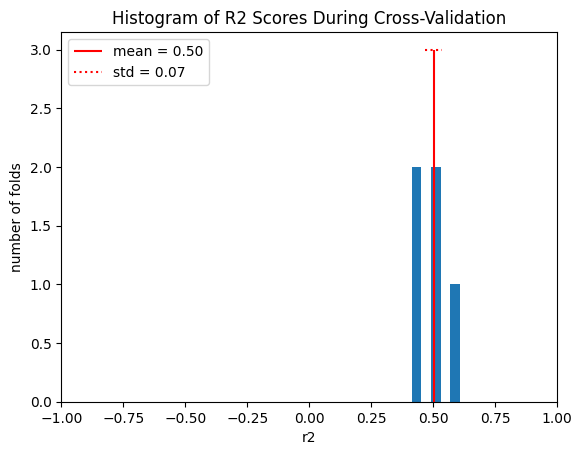

In [25]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor(n_estimators=100)

cv_results = cross_validate(forest, X, y, scoring = "r2", cv=5)

plot_histogram_cv_results(cv_results)


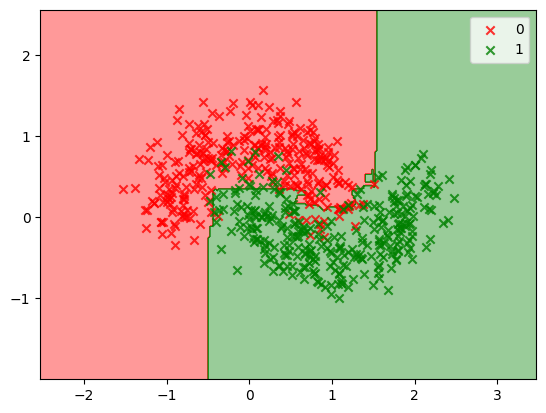

In [26]:
from sklearn.ensemble import RandomForestClassifier

#@interact(max_depth=5)
def plot_classifier(max_depth):
    cls = RandomForestClassifier(max_depth=max_depth)
    cls.fit(X_moon, y_moon)
    plot_decision_regions(X_moon, y_moon, classifier=cls)

plot_classifier(max_depth=5)

## 💻 Bagging any Algorithm (not just Trees)!

Bagging can be implemented on any algorithm using either the [`BaggingRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingRegressor.html) or the [`BaggingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html)

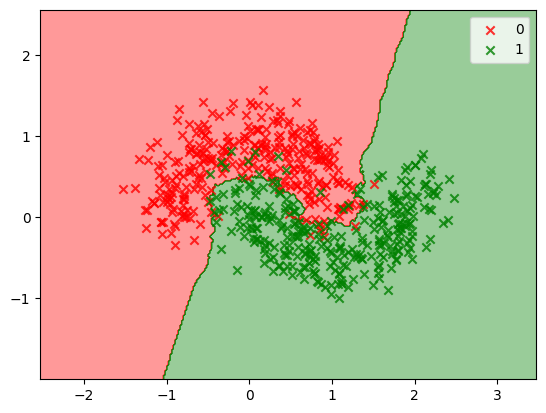

In [27]:
from sklearn.ensemble import BaggingClassifier, BaggingRegressor
from sklearn.neighbors import KNeighborsClassifier

weak_learner = KNeighborsClassifier(n_neighbors=3)
bagged_model = BaggingClassifier(weak_learner, n_estimators=40)

bagged_model.fit(X_moon, y_moon)
plot_decision_regions(X_moon, y_moon, classifier=bagged_model)

#### Out-of-Bag Samples  
Sample not "drawn" by the bagging can be used to give a pseudo "test" score

In [28]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

bagged_model = BaggingRegressor(linear_model,
                                n_estimators=50,
                                oob_score=True)

bagged_model.fit(X, y).oob_score_

0.5019137975250715

💡 Notice
```python
RandomForestClassifier(n_estimators=100)
BaggingClassifier(DecisionTreeClassifier(), n_estimators=100)  # similar (but slightly less optimized)
```

```python
BaggingRegressor(RandomForestClassifier(), n_estimators=100)  # bad time! 10,000 trees to train!
```

### Pros and Cons of Bagging

👍 Advantages:
- Reduces variance (overfitting)
- Can be applied to any model

👎 Disadvantages
- Complex structure
- Long training time
- Disregards the performance of individual sub-models

# 3. Boosting

Boosting is a method designed to train weak learners that learn from their predecessor's mistakes

- It is a **sequential** ensemble method
- The aim of boosting is to **reduce bias**
- Focuses on the observations that are harder to predict
- The best weak learners are given more weight in the final vote

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/binary_decision_tree_vs_random_forest_vs_boosted_trees.png' width=600 style='margin:auto' align = center> 


## 3.1 AdaBoost (Adaptative Boosting)

[`AdaBoostRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostRegressor.html) and [`AdaBoostClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html)

**One implementation** of boosting that works particularly well with trees

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/adaboost_albon.png' width=700 style='margin:auto' align = center> 

### 💻 AdaBoosted Trees in Sklearn

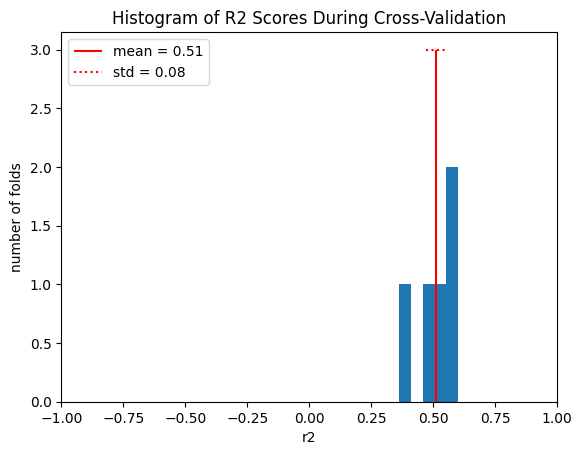

In [29]:
from sklearn.ensemble import AdaBoostRegressor

adaboost = AdaBoostRegressor(
    DecisionTreeRegressor(max_depth=3),
    n_estimators=50)

cv_results = cross_validate(adaboost, X, y, scoring = "r2", cv=5)

plot_histogram_cv_results(cv_results)

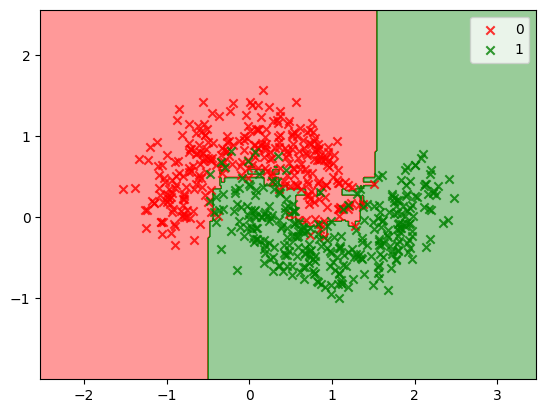

In [30]:
from sklearn.ensemble import AdaBoostClassifier

#@interact(n_estimators=[10, 30, 50,100], max_depth=3)
def plot_classifier(n_estimators, max_depth):
    model = AdaBoostClassifier(DecisionTreeClassifier(max_depth=max_depth),
                               n_estimators=n_estimators)
    model.fit(X_moon, y_moon)
    plot_decision_regions(X_moon, y_moon, classifier=model)

plot_classifier(n_estimators=50, max_depth=3)

## 3.2 Gradient Boosting 🔥

- Only implemented for trees
- Generally performs better than AdaBoost

Instead of updating the weights of observations that were misclassified, Gradient Boosting will
1. Recursively fit each weak learner $d_\text{tree i}$ so as to predict the **residuals** of the previous one
2. **Add** all the predictions of all weak learners

$$D(\mathbf{x}) = d_\text{tree 1}(\mathbf{x}) + d_\text{tree 2}(\mathbf{x}) + ...+ d_\text{tree n}(\mathbf{x})$$

For classification, the principle is similar, but in the logit space (if `log-loss` is chosen as a loss function)

📚 scikit-learn [user guide](https://scikit-learn.org/stable/modules/ensemble.html#gradient-boosting) <br>
📚 Brilliantly Wrong [visual blog post](https://arogozhnikov.github.io/2016/06/24/gradient_boosting_explained.html)

### a) scikit-learn [GradientBoostingRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html) and [GradientBoostingClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html)

```python
from sklearn.ensemble import GradientBoostingRegressor
model = GradientBoostingRegressor(
    n_estimators=100, 
    learning_rate=0.1,
    max_depth=3
)
```

### b) [XGBOOST](https://xgboost.readthedocs.io/en/latest/) (Extreme Gradient Tree Boosting)

- Dedicated library, optimized for this task
- Nice features inspired by Deep Learning

First, let's split the dataset into train, test and validation sets

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/data_training_needs_transparent.png" width=600 style='margin:auto' align = center>

**Splitting the Data**

```python
from sklearn.model_selection import train_test_split

# Split data into train, test and validation sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = 42  # TEST = 30%
)

# Use the same function above for the validation set
X_test, X_val, y_test, y_val = train_test_split(
    X_test, y_test, test_size = 0.5, random_state = 42  # TEST = 15%
)
```

Then, we plug the data into the `XGBRegressor`!

```python
from xgboost import XGBRegressor

xgb_reg = XGBRegressor(max_depth=10, n_estimators=100, learning_rate=0.1)

xgb_reg.fit(X_train, y_train,
    # evaluate loss at each iteration
    eval_set=[(X_train, y_train), (X_val, y_val)],  
    # stop iterating when eval loss increases 5 times in a row
    early_stopping_rounds=5
)

y_pred = xgb_reg.predict(X_val)
```

&nbsp;

Or integrate it into `scikit-learn` as a Pipeline 🎉

```python
from sklearn.pipeline import make_pipeline

pipe_xgb = make_pipeline(xgb_reg)
cv_results = cross_validate(pipe_xgb, X, y, cv=10, scoring='r2')
```

## Pros and Cons of Boosting

👍 Advantages:
- Strong sub-models have more influence in final decision
- Reduces bias

👎 Disadvantages:
- Computationally expensive (sequential)
- Easily overfits
- Sensitive to outliers (too much time spent trying to correctly predict them)


## <font color=red>Ensemble Methods Summary</font>

Ensemble learning combines several base algorithms, like Decision Trees  
Ensemble methods can be broken down into two categories:

**Parallel learners**:  models trained in parallel; predictions are aggregated 
- `RandomForestRegressors`
- `BaggingRegressors`
    

**Sequential learners**: models trained sequentially so as to learn from predecessors' mistakes
- `AdaBoostRegressor`
- `GradientBoostRegressor`
- `XGBoostRegressor`

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/binary_decision_tree_vs_random_forest_vs_boosted_trees.png' width=500 style='margin:auto' align = center> 

# 4. Stacking

<br>

Training **different estimators** and aggregating their predictions

- Different estimators (KNN, LogReg, etc.) capture **different structures in the data**
- Combining sometimes enhances the predictive power
- The results are aggregated either by voting (classification) or averaging (regression)

### a) Simple aggregation

scikit-learn [VotingClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.VotingClassifier.html) and [VotingRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.VotingRegressor.html)

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/ensemble_models.png' width=600 style='margin:auto' align = center> 


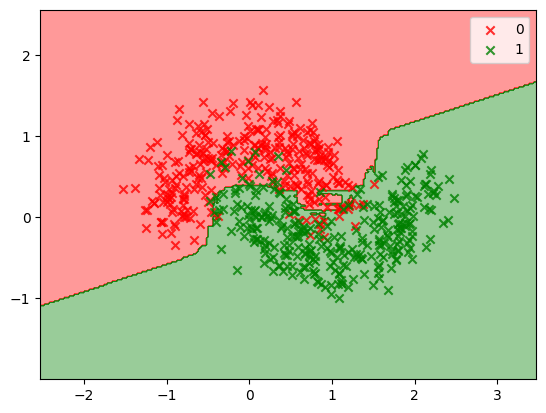

In [31]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression

forest = RandomForestClassifier()
logreg = LogisticRegression()

ensemble = VotingClassifier(
    estimators = [("rf", forest),("lr", logreg)],
    voting = 'soft', # to use predict_proba of each classifier before voting
    weights = [1,1] # to equally weight forest and logreg in the vote
)
ensemble.fit(X_moon, y_moon)
plot_decision_regions(X_moon, y_moon, classifier=ensemble)

🤔 How do you choose the best weights?

### b) Multi-layer Stacking!

Train a **final estimator** on the predictions of the previous ones

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/stacking.png" width=600>


scikit-learn [StackingClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingClassifier.html) and [StackingRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingRegressor.html)


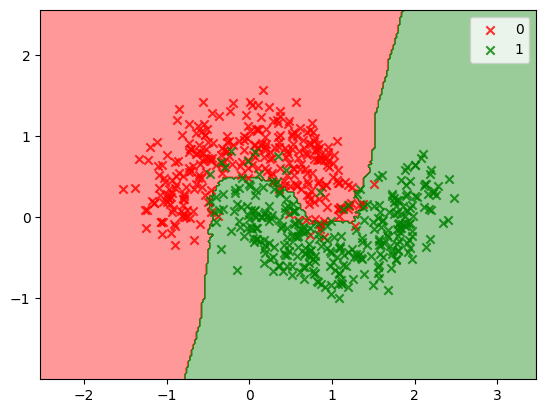

In [32]:
from sklearn.ensemble import StackingClassifier
from sklearn.neighbors import KNeighborsClassifier

ensemble = StackingClassifier(
    estimators = [("rf", RandomForestClassifier()),
                  ("knn", KNeighborsClassifier(n_neighbors=10))],
    final_estimator = LogisticRegression())

ensemble.fit(X_moon, y_moon)
plot_decision_regions(X_moon, y_moon, classifier=ensemble)

## Bibliography

- 📚[Visual Introduction to Decision Tree](http://www.r2d3.us/visual-intro-to-machine-learning-part-1/)
- 📚[Brilliantly Wrong - visual blog on Gradient Boosting](https://arogozhnikov.github.io/2016/06/24/gradient_boosting_explained.html)
- 📄 [Ensemble methods under the hood](https://towardsdatascience.com/ensemble-methods-bagging-boosting-and-stacking-c9214a10a205)

# Your Turn! 🚀